# Análise Exploratória — Football Manager 2023

Notebook de EDA inicial sobre o dataset `merged_players.csv`, derivado do *Football Manager 2023 Dataset* (Kaggle).

**Objetivo:** inspecionar a estrutura, tipos e distribuições do conjunto de dados antes de qualquer modelagem de similaridade entre jogadores.

---

## 1. Setup

Importação das bibliotecas utilizadas no notebook. `matplotlib`/`seaborn` para visualizações; `numpy` apenas para utilitários numéricos pontuais.

In [2]:
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid", context="notebook")

## 2. Carregamento dos dados

Resolve a raiz do projeto a partir do marcador `.git` para construir um caminho independente do diretório de execução, e carrega o CSV consolidado de jogadores.

In [3]:
from pathlib import Path


def project_root(marker: str = ".git") -> Path:
    for parent in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Marker {marker!r} not found in any parent of {Path.cwd()}")


DATA_DIR = project_root() / "data"

df_players = pd.read_csv(DATA_DIR / "merged_players (1).csv")
df_players.shape

(91672, 88)

## 3. Estrutura do dataset

Visão geral das colunas, tipos e ausência de valores. Útil para detectar campos com tipos inadequados ou alta incidência de nulos.

In [4]:
df_players.info()

<class 'pandas.DataFrame'>
RangeIndex: 91672 entries, 0 to 91671
Data columns (total 88 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Unnamed: 0         91672 non-null  int64
 1   UID                91672 non-null  int64
 2   Name               91672 non-null  str  
 3   Rec                91672 non-null  str  
 4   DOB                91672 non-null  str  
 5   Inf                37304 non-null  str  
 6   Club               80291 non-null  str  
 7   Based              91672 non-null  str  
 8   Nat                91672 non-null  str  
 9   Height             91672 non-null  str  
 10  Weight             91672 non-null  str  
 11  Age                91672 non-null  int64
 12  Position           91672 non-null  str  
 13  Transfer Value     91672 non-null  str  
 14  Media Description  91672 non-null  str  
 15  Rc Injury          91672 non-null  str  
 16  Preferred Foot     91672 non-null  str  
 17  Left Foot          9167

## 4. Estatísticas descritivas

Resumo estatístico das colunas numéricas: medidas de tendência central, dispersão e quartis. Permite identificar outliers grosseiros e escalas distintas entre atributos.

In [5]:
df_players.describe()

,Unnamed: 0,UID,Age,Caps,Acc,Wor,Vis,Thr,Tec,Tea,Tck,Str,Sta,TRO,Ref,Pun,Pos,Pen,Pas,Pac,1v1,OtB,Nat.1,Mar,L Th,Lon,Ldr,Kic,Jum,Hea,Han,Fre,Fla,Fir,Fin,Ecc,Dri,Det,Dec,Cro,Cor,Cnt,Cmp,Com,Cmd,Bra,Bal,Ant,Agi,Agg,Aer,Vers,Temp,Spor,Prof,Pres,Loy,Inj Pr,Imp M,Dirt,Amb,Ada,Cons,Cont
count,91672.000000,9.167200e+04,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.00000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.000000,91672.00000,91672.000000
mean,45835.500000,6.778839e+08,24.153155,1.684386,11.629385,10.259447,8.581464,2.780042,9.789772,9.529529,8.155206,8.437178,9.803441,2.876102,3.122273,2.858485,8.905587,5.888701,9.787820,11.428473,2.859946,8.748767,12.003098,7.563531,5.137567,7.14505,8.376713,2.934069,9.394297,8.212148,3.062255,6.527184,8.368553,9.979470,7.527031,2.574265,8.235612,10.827036,10.867266,7.540296,6.379211,8.978543,9.027915,2.822225,2.881589,9.402511,9.209802,9.728990,11.291987,10.319389,3.015075,11.080897,13.722663,11.087540,11.418536,11.023486,11.135385,8.682346,9.480114,8.896348,11.178571,12.730987,11.38449,5.442622
std,26463.571276,9.166062e+08,5.611517,9.032262,2.109759,2.830064,3.006093,2.372539,3.248700,2.963630,4.066333,3.422840,3.235839,2.634367,3.237048,2.608447,2.963177,3.579618,2.640057,2.041350,2.563798,3.543561,2.555821,3.564135,3.168144,3.29688,3.550868,2.739296,3.387952,3.670485,3.055368,3.066285,3.760302,3.124251,3.753018,1.908456,3.917111,4.000594,2.302411,3.631859,2.901067,2.636756,2.674988,2.453636,2.572732,3.237702,2.914766,2.540873,2.073292,3.069449,2.961125,2.870451,3.545223,2.109318,2.048462,1.846519,2.044249,3.130387,3.972640,3.075600,2.107911,3.963633,3.20583,3.036017
min,0.000000,1.113300e+04,15.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
25%,22917.750000,1.939872e+07,19.000000,0.000000,10.000000,8.000000,7.000000,1.000000,8.000000,7.000000,5.000000,6.000000,8.000000,1.000000,1.000000,1.000000,7.000000,3.000000,8.000000,10.000000,1.000000,6.000000,11.000000,5.000000,3.000000,5.00000,6.000000,1.000000,7.000000,6.000000,1.000000,5.000000,5.000000,8.000000,5.000000,1.000000,5.000000,8.000000,9.000000,5.000000,4.000000,7.000000,7.000000,1.000000,1.000000,7.000000,7.000000,8.000000,10.000000,8.000000,1.000000,9.000000,11.000000,10.000000,10.000000,10.000000,10.000000,6.000000,7.000000,6.000000,10.000000,10.000000,9.00000,3.000000
50%,45835.500000,6.724837e+07,24.000000,0.000000,12.000000,10.000000,9.000000,2.000000,10.000000,9.000000,8.000000,8.000000,10.000000,2.000000,2.000000,2.000000,9.000000,5.000000,10.000000,12.000000,2.000000,9.000000,12.000000,8.000000,5.000000,7.00000,9.000000,2.000000,9.000000,8.000000,2.000000,6.000000,8.000000,10.000000,8.000000,2.000000,9.000000,12.000000,11.000000,8.000000,6.000000,9.000000,9.000000,2.000000,2.000000,9.000000,9.000000,10.000000,11.000000,10.000000,2.000000,11.000000,14.000000,11.0000

## 5. Higiene inicial: índice residual, duplicatas e coluna constante

Antes de qualquer análise substantiva, identificamos artefatos de origem do CSV:

- A coluna `Unnamed: 0` é o índice posicional gerado pelo `to_csv` na etapa de merge — não carrega informação.
- A coluna `Rec` (Reputation) contém apenas o valor `"- - -"` em todas as linhas — variância zero, descartável.
- Registros com `UID` repetido podem indicar que o mesmo jogador apareceu em mais de um arquivo durante o merge.

Confirmamos numericamente cada ponto antes de remover qualquer coluna.

In [6]:
constant_cols = [c for c in df_players.columns if df_players[c].nunique(dropna=False) == 1]
print("Colunas constantes:", constant_cols)
print("Unnamed: 0 é único?", df_players["Unnamed: 0"].is_unique)

uid_dups = df_players["UID"].duplicated().sum()
print(f"Linhas com UID duplicado: {uid_dups} ({uid_dups / len(df_players):.2%})")

Colunas constantes: ['Rec']
Unnamed: 0 é único? True
Linhas com UID duplicado: 4509 (4.92%)


Quando duas linhas compartilham o mesmo `UID`, verificamos quais colunas de fato diferem entre elas. Se a única diferença for o índice residual, a deduplicação é segura.

In [7]:
dup_mask = df_players["UID"].duplicated(keep=False)
sample_uid = df_players.loc[dup_mask, "UID"].iloc[0]
sample = df_players[df_players["UID"] == sample_uid]

diff_cols = [c for c in df_players.columns if sample[c].nunique(dropna=False) > 1]
print(f"UID de exemplo: {sample_uid}")
print(f"Colunas que diferem entre as cópias: {diff_cols}")

UID de exemplo: 29114887
Colunas que diferem entre as cópias: ['Unnamed: 0']


Como a única diferença é o índice residual, removemos `Unnamed: 0`, `Rec` e linhas duplicadas por `UID`. O resultado fica armazenado em `df` para o restante da análise.

In [7]:
df = (
    df_players
    .drop(columns=["Unnamed: 0", "Rec"])
    .drop_duplicates(subset="UID")
    .reset_index(drop=True)
)
print(f"Antes: {df_players.shape}  ->  Depois: {df.shape}")

Antes: (91672, 88)  ->  Depois: (87163, 86)


## 6. Mapa de valores ausentes

Os atributos de 1–20 não têm nulos (típico do export de FM, em que todo jogador possui valor para todo atributo). A ausência se concentra em colunas categóricas opcionais. Quantificamos:

In [8]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.concat([missing.rename("n_null"), missing_pct.rename("pct_null")], axis=1)

,n_null,pct_null
Team,81852,93.91
Inf,51194,58.73
Club,10801,12.39


- `Team` (designação interna do elenco — U19/U21/Main) só é preenchida para uma fração mínima dos jogadores; tem uso semântico restrito.
- `Inf` (status — _Wanted_, _Loan_, _Injured_, etc.) só faz sentido quando aplicável; a ausência **é** a informação "sem status".
- `Club` ausente indica jogador sem clube no snapshot.

Nenhum atributo de habilidade (1–20) está ausente, o que é determinante para a etapa de similaridade.

## 7. Categorização das colunas

O dataset traz 86 colunas após a limpeza. Para a EDA, separá-las por **família semântica** facilita a leitura — em vez de tratar 86 colunas como uma sopa única, agrupamos:

- **Identificação / metadados**: `UID`, `Name`, `DOB`, `Inf`, `Club`, `Based`, `Nat`, `Team`.
- **Físico bruto (string)**: `Height`, `Weight` — vêm formatados (`5'9"`, `65 kg`) e exigem parsing antes de virar feature.
- **Mercado**: `Transfer Value` — intervalo `min$ - max$` em string.
- **Tático / posicional**: `Position`, `Preferred Foot`, `Left Foot`, `Right Foot`.
- **Histórico de jogo**: `Age`, `Caps`, `AT Apps`, `AT Gls`, `AT Lge Apps`, `AT Lge Gls`, `Yth Apps`, `Yth Gls`.
- **Mídia / contrato**: `Media Description`, `Media Handling`, `Rc Injury`.
- **Atributos 1–20**: o núcleo da modelagem. Subdivididos abaixo em quatro famílias do próprio FM (Técnico, Mental, Físico, Goleiro) mais um bloco "hidden" (personalidade/desenvolvimento) que o jogo expõe via editor.

A separação Técnico/Mental/Físico/GK segue a documentação oficial do Football Manager. Os atributos *hidden* (personalidade, lealdade, ambição etc.) são tratados à parte por terem uma natureza diferente das habilidades em campo.

In [12]:
ATTR_GROUPS = {
    "Técnico": [
        "Cor", "Cro", "Dri", "Fin", "Fir", "Fre", "Hea", "Lon",
        "L Th", "Mar", "Pas", "Pen", "Tck", "Tec",
    ],
    "Mental": [
        "Agg", "Ant", "Bra", "Cmp", "Cnt", "Dec", "Det", "Fla",
        "Ldr", "OtB", "Pos", "Tea", "Vis", "Wor",
    ],
    "Físico": [
        "Acc", "Agi", "Bal", "Jum", "Nat.1", "Pac", "Sta", "Str",
    ],
    "Goleiro": [
        "Aer", "Cmd", "Com", "Ecc", "Han", "Kic", "1v1", "Ref",
        "TRO", "Pun", "Thr",
    ],
    "Hidden / Personalidade": [
        "Vers", "Temp", "Spor", "Prof", "Pres", "Loy", "Inj Pr",
        "Imp M", "Dirt", "Amb", "Ada", "Cons", "Cont",
    ],
}

for grp, cols in ATTR_GROUPS.items():
    missing = [c for c in cols if c not in df.columns]
    print(f"{grp:25s} {len(cols):2d} cols  | faltando: {missing or 'nenhuma'}")

all_attrs = [c for cols in ATTR_GROUPS.values() for c in cols]
print(f"\nTotal de atributos 1-20 mapeados: {len(all_attrs)}")
print(f"Atributos numéricos não classificados: {sorted(set(df.select_dtypes('number').columns) - set(all_attrs) - {'UID', 'Age', 'Caps'})}")

Técnico                   14 cols  | faltando: nenhuma
Mental                    14 cols  | faltando: nenhuma
Físico                     8 cols  | faltando: nenhuma
Goleiro                   11 cols  | faltando: nenhuma
Hidden / Personalidade    13 cols  | faltando: nenhuma

Total de atributos 1-20 mapeados: 60
Atributos numéricos não classificados: []


## 8. Distribuição dos atributos 1–20 por família

Histogramas empilhados por família. O objetivo é responder, de relance: **as distribuições estão centradas no esperado?** Para a maioria dos atributos do FM, esperamos uma distribuição aproximadamente normal centrada em torno de 10, com cauda longa nos valores altos (jogadores de elite são raros).

Atributos de goleiro **não** seguem essa lógica: jogadores de linha têm valores baixíssimos nessas colunas (e vice-versa), produzindo uma distribuição bimodal artificial. É exatamente o que veremos.

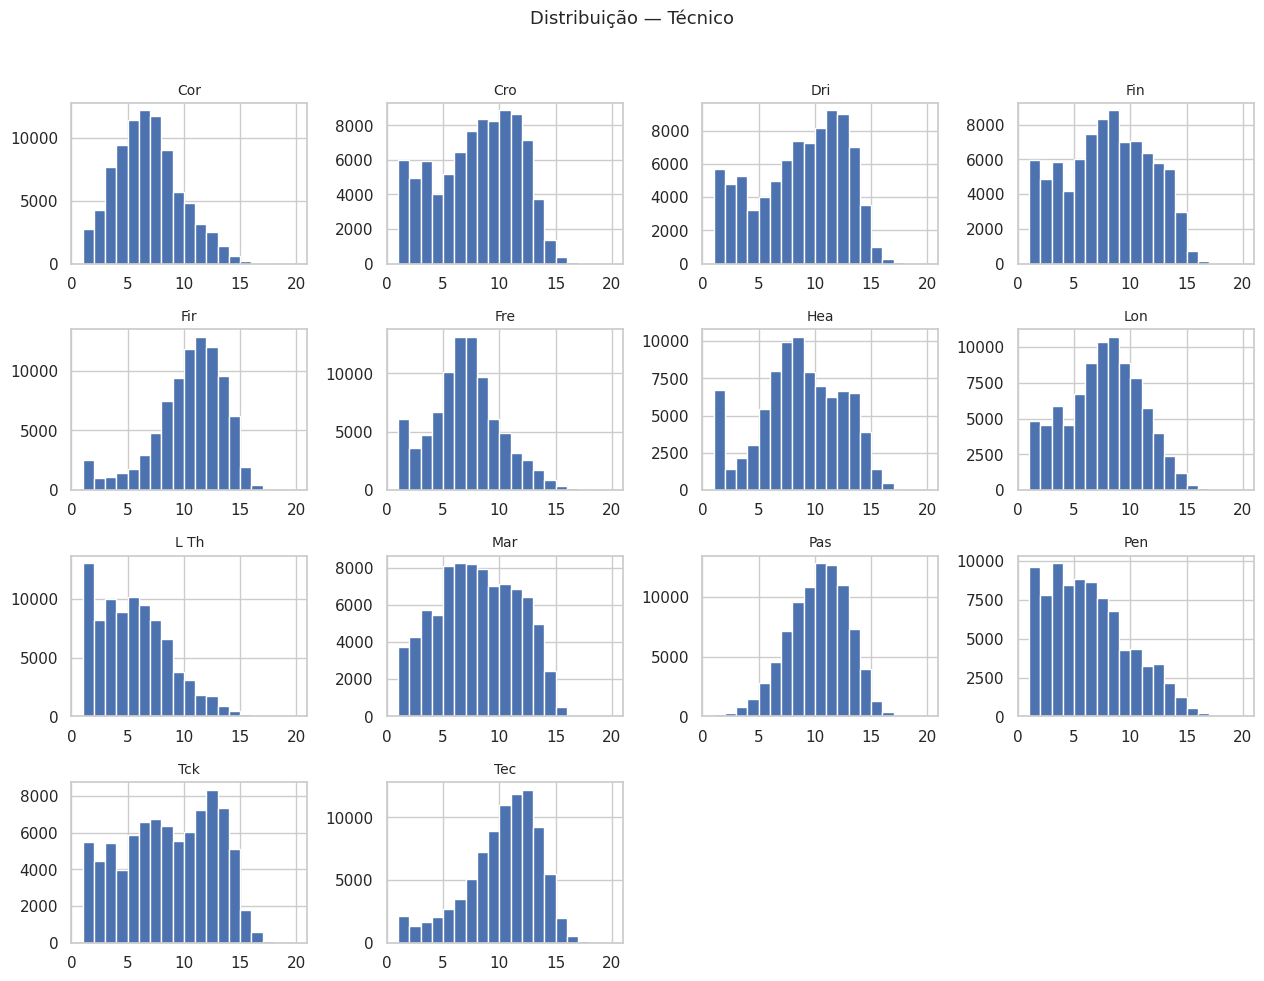

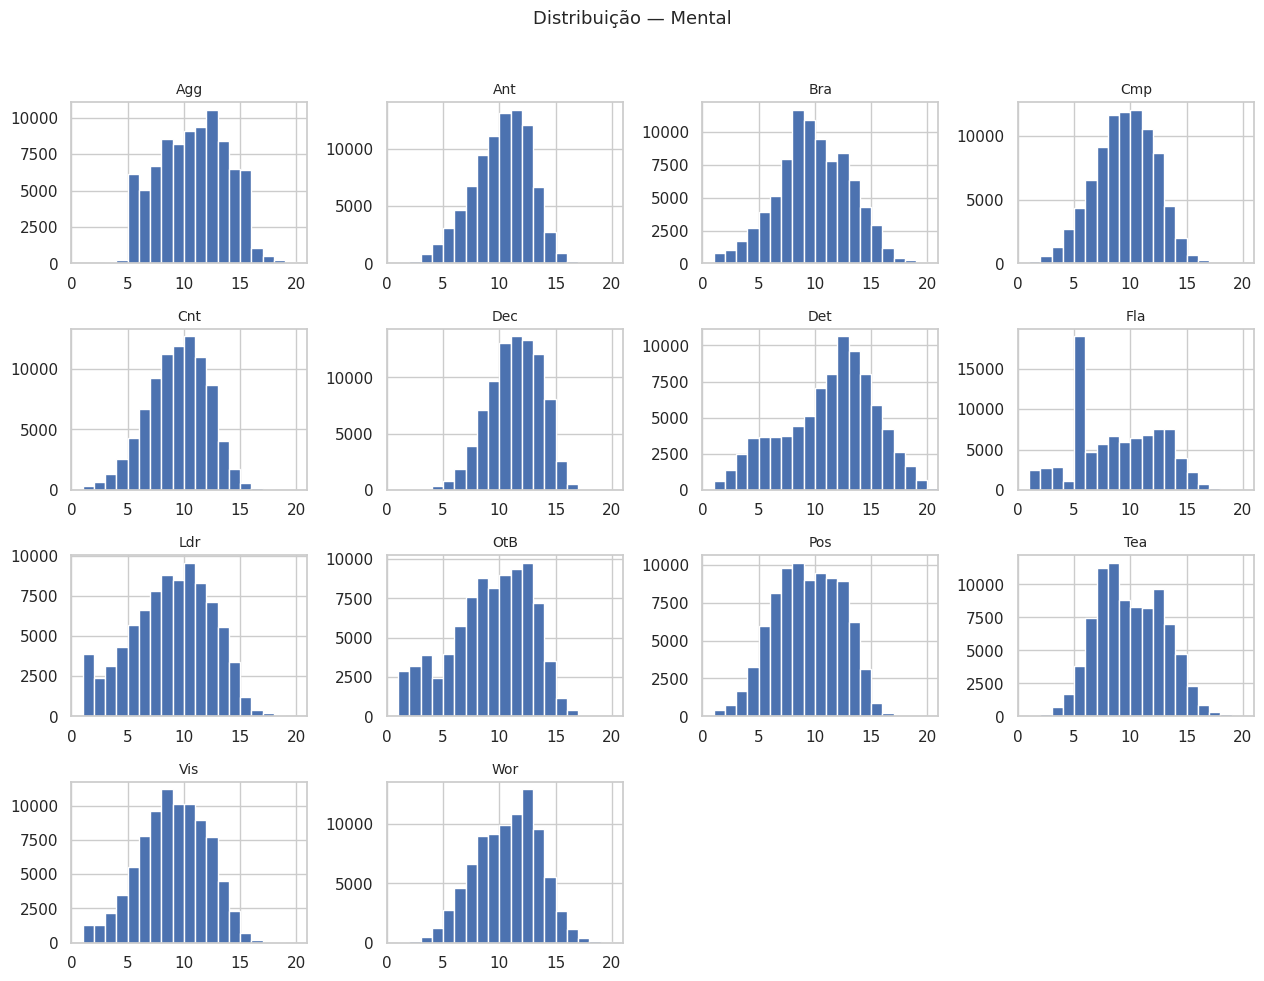

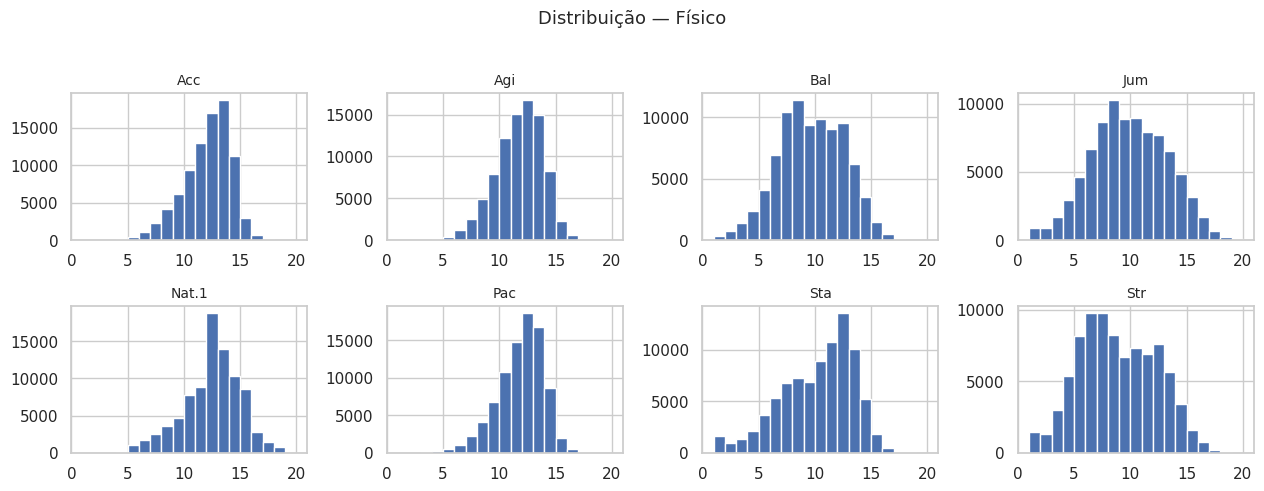

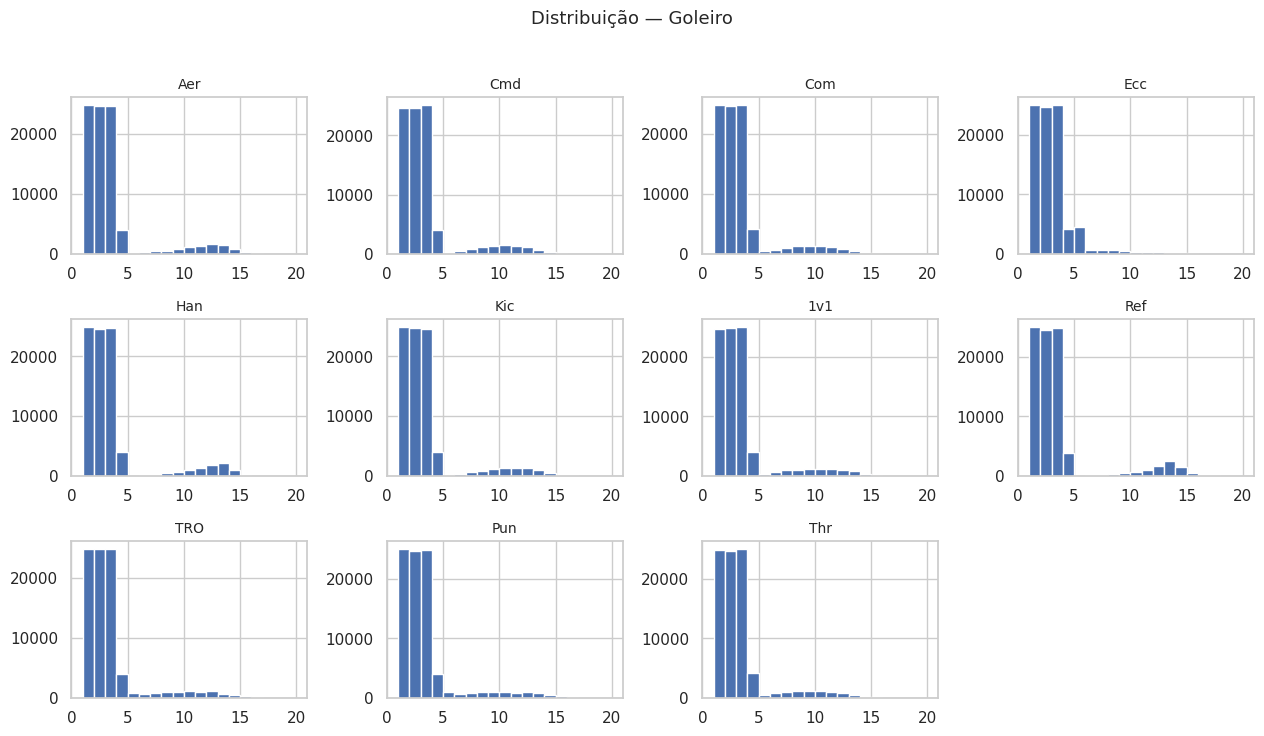

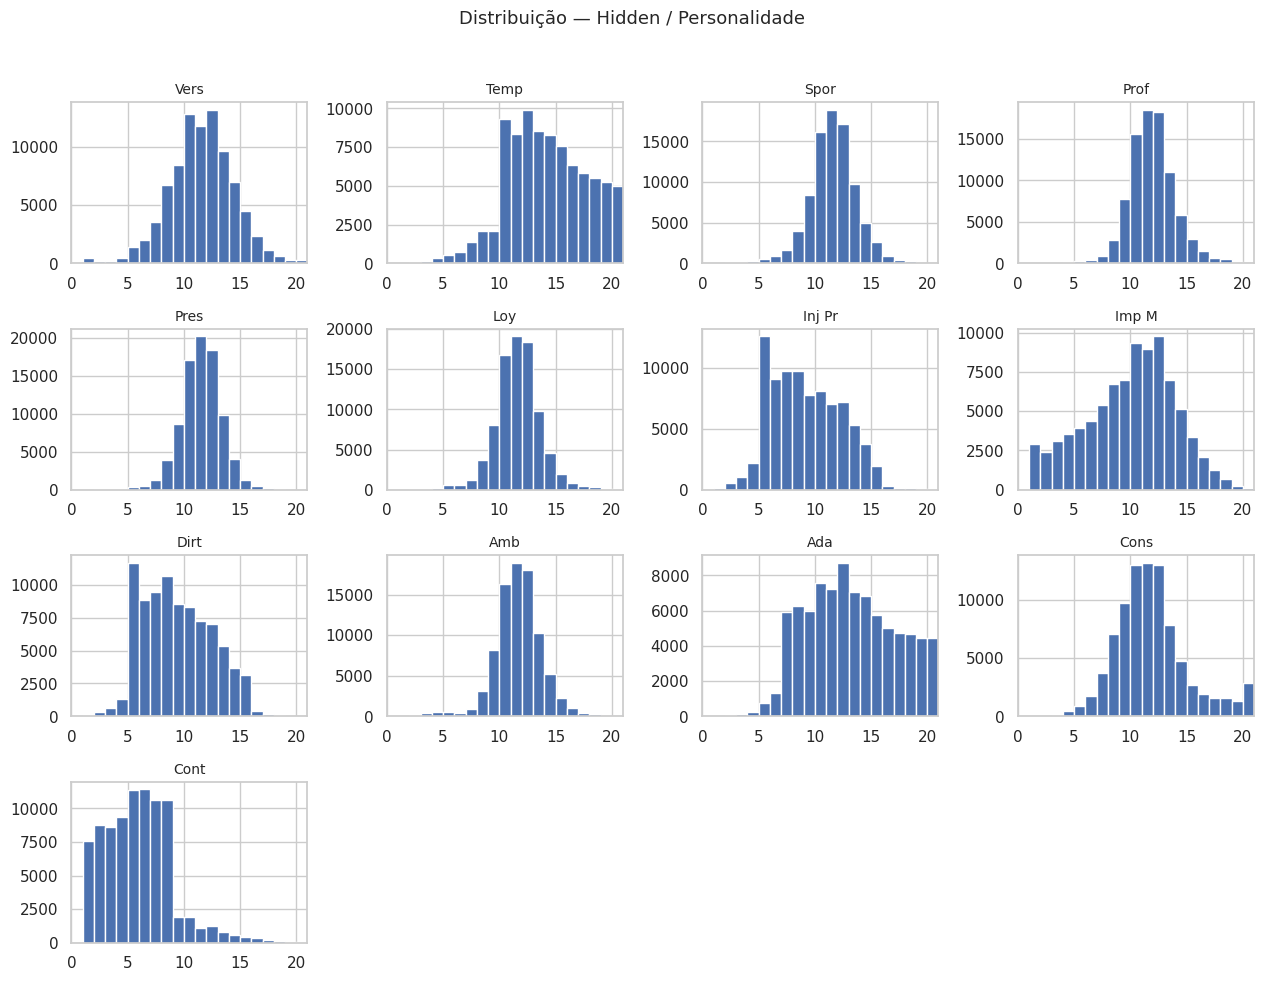

In [13]:
def plot_group(group_name, cols, ncols=4):
    rows = -(-len(cols) // ncols)
    fig, axes = plt.subplots(rows, ncols, figsize=(3.2 * ncols, 2.4 * rows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, cols):
        ax.hist(df[col], bins=range(1, 22), color="#4C72B0", edgecolor="white")
        ax.set_title(col, fontsize=10)
        ax.set_xlim(0, 21)
    for ax in axes[len(cols):]:
        ax.axis("off")
    fig.suptitle(f"Distribuição — {group_name}", fontsize=13, y=1.02)
    fig.tight_layout()
    plt.show()


for grp, cols in ATTR_GROUPS.items():
    plot_group(grp, cols)

In [14]:
# Verifica todos os possíveis valores da coluna Position
print("Valores únicos em Position:", df["Position"].unique())

Valores únicos em Position: <StringArray>
[                        'AM (R)',                          'M (C)',
                             'GK',                          'D (C)',
                         'D (LC)',                         'AM (C)',
                          'M (L)',                         'ST (C)',
                       'AM (RLC)',                      'DM, M (C)',
 ...
                 'D (R), M (RLC)',        'M (RC), AM (RL), ST (C)',
                  'D (C), AM (R)', 'D/WB (R), DM, M (RC), AM (RLC)',
               'D (C), M/AM (RC)',       'D (C), WB (R), DM, M (C)',
              'D (RC), M/AM (RL)',                 'WB (R), M (LC)',
       'D (RL), M (RLC), AM (RL)',     'D (RLC), WB (L), DM, M (L)']
Length: 628, dtype: str


## 9. Extração do papel primário a partir de `Position`

A coluna `Position` codifica todas as posições jogáveis por um atleta em uma única string com convenção própria do FM:

- `D (C)` — _Defender, Centre_
- `AM (RL), ST (C)` — atua como meia-atacante pelos lados **e** como centroavante
- `D/WB (R)` — defensor **ou** lateral pela direita

Existem mais de 600 combinações distintas. Para a EDA — e para qualquer agrupamento "por posição" — precisamos reduzir essa string a um **papel primário**. A heurística adotada:

1. Goleiro (`GK`) → `GK`.
2. Caso contrário, escolhe-se o **primeiro token** da string (a primeira posição listada pelo FM costuma ser a principal).
3. Esse token é mapeado para um dos grandes blocos: `GK`, `DEF`, `WB`, `DM`, `MID`, `AM`, `FW`.

É uma simplificação consciente — perde-se a versatilidade do jogador. Para análises de similaridade, planeja-se posteriormente representar a posição como vetor binário (uma posição por dimensão). Para a EDA, o papel primário basta.

In [17]:
ROLE_MAP = {
    "GK": "GK",
    "D": "DEF",
    "WB": "WB",
    "DM": "DM",
    "M": "MID",
    "AM": "AM",
    "ST": "FW",
}


def primary_role(pos_str: str) -> str:
    first_token = pos_str.split(",")[0].strip()
    base = re.split(r"[/ (]", first_token)[0]
    return ROLE_MAP.get(base, "OTHER")

print(df.shape)
df["primary_role"] = df["Position"].map(primary_role)
df["primary_role"].value_counts()

(87163, 87)


primary_role
DEF    29946
MID    15738
AM     12930
FW      9717
DM      9179
GK      8880
WB       773
Name: count, dtype: int64

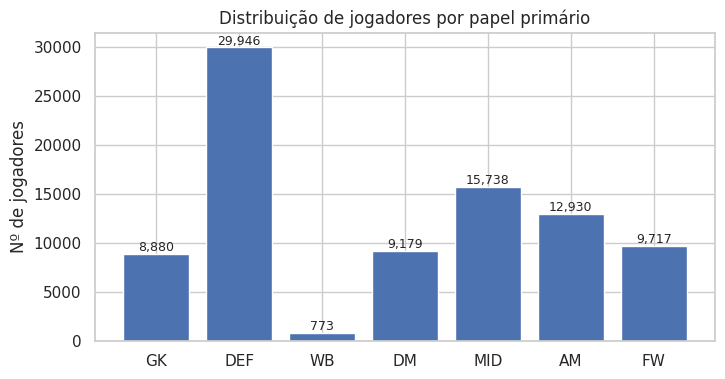

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
order = ["GK", "DEF", "WB", "DM", "MID", "AM", "FW"]
counts = df["primary_role"].value_counts().reindex(order).fillna(0)
ax.bar(counts.index, counts.values, color="#4C72B0")
ax.set_title("Distribuição de jogadores por papel primário")
ax.set_ylabel("Nº de jogadores")
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{int(v):,}", ha="center", va="bottom", fontsize=9)
plt.show()

A distribuição reflete a estrutura de uma escalação: muitos defensores e centroavantes (posições "densas" em qualquer elenco), número grande de goleiros (todo clube tem 3–4) e meias mais espalhados entre `DM`, `MID` e `AM`.

## 10. Perfis médios por posição

A pergunta-chave da EDA, dado o objetivo do estudo de similaridade: **os atributos 1–20 conseguem, sozinhos, discriminar funções táticas?** Se a resposta for sim, qualquer métrica de distância razoável já deve agrupar goleiros longe de atacantes.

Para visualizar isso, calculamos a **média de cada atributo por papel primário** e plotamos como heatmap. Padrões esperados:

- Goleiros: valores altos em atributos GK, baixos em quase tudo o mais.
- Defensores centrais: altos em `Mar`, `Tck`, `Hea`, `Str`, `Jum`.
- Atacantes: altos em `Fin`, `OtB`, `Cmp`, `Pac`.

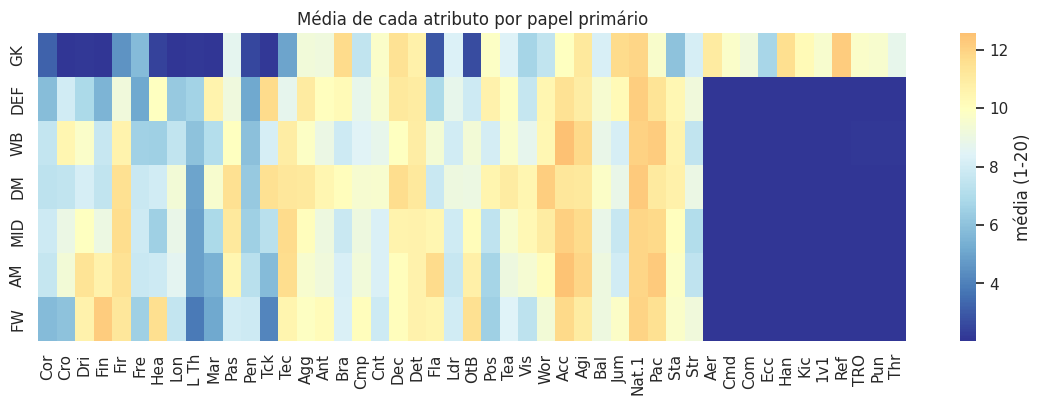

In [13]:
attr_cols = [c for grp, cols in ATTR_GROUPS.items() for c in cols if grp != "Hidden / Personalidade"]
role_means = df.groupby("primary_role")[attr_cols].mean().reindex(["GK", "DEF", "WB", "DM", "MID", "AM", "FW"])

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(role_means, cmap="RdYlBu_r", center=10, annot=False, cbar_kws={"label": "média (1-20)"}, ax=ax)
ax.set_title("Média de cada atributo por papel primário")
ax.set_xlabel("")
ax.set_ylabel("")
plt.show()

O contraste do bloco de goleiros é evidente: a linha `GK` "acende" exatamente nas colunas de atributos de goleiro (`Aer`, `Cmd`, `Han`, `Kic`, `1v1`, `Ref`, ...) e fica praticamente apagada nos atributos técnicos de jogador de linha (`Dri`, `Fin`, `Pas`).

Esse padrão valida uma decisão metodológica importante para o estudo de similaridade: **separar goleiros dos jogadores de linha** antes de aplicar qualquer métrica de distância no espaço de atributos. Misturá-los inflaria artificialmente a variância em metade das colunas e dominaria qualquer ranking de similaridade.

## 11. Colunas string que precisam de parsing

Três colunas trazem informação numérica embutida em string e exigem normalização antes de qualquer modelagem:

| Coluna | Formato | Tratamento sugerido |
|---|---|---|
| `Height` | `5'9"` (pés/polegadas) | converter para cm |
| `Weight` | `65 kg` | extrair número |
| `Transfer Value` | `200K$ - 2M$` (intervalo) | extrair mínimo, máximo e média |

Aqui apenas mostramos a estrutura e fazemos um parse de demonstração. A persistência da versão limpa fica para o pipeline de pré-processamento, fora deste notebook.

In [14]:
def height_to_cm(h: str) -> float:
    m = re.match(r"(\d+)'(\d+)\"", h)
    if not m:
        return np.nan
    feet, inches = map(int, m.groups())
    return round((feet * 12 + inches) * 2.54, 1)


def weight_to_kg(w: str) -> float:
    m = re.match(r"(\d+)\s*kg", w)
    return float(m.group(1)) if m else np.nan


_MULT = {"K": 1_000, "M": 1_000_000}


def _value_to_number(token: str) -> float:
    token = token.strip().replace("$", "")
    m = re.match(r"([\d.]+)([KM]?)", token)
    if not m:
        return np.nan
    num, suffix = m.groups()
    return float(num) * _MULT.get(suffix, 1)


def transfer_value_bounds(v: str) -> tuple[float, float]:
    if " - " in v:
        lo, hi = v.split(" - ")
        return _value_to_number(lo), _value_to_number(hi)
    n = _value_to_number(v)
    return n, n


preview = df[["Name", "Height", "Weight", "Transfer Value"]].head(5).copy()
preview["Height_cm"] = preview["Height"].map(height_to_cm)
preview["Weight_kg"] = preview["Weight"].map(weight_to_kg)
preview[["TV_min", "TV_max"]] = preview["Transfer Value"].apply(lambda s: pd.Series(transfer_value_bounds(s)))
preview

,Name,Height,Weight,Transfer Value,Height_cm,Weight_kg,TV_min,TV_max
0,Scott King,"5'9""",65 kg,0$,175.3,65.0,0.0,0.0
1,José González,"5'4""",56 kg,0$,162.6,56.0,0.0,0.0
2,Chase Crane,"6'2""",77 kg,0$,188.0,77.0,0.0,0.0
3,Emmanuel Araiza,"6'1""",74 kg,0$,185.4,74.0,0.0,0.0
4,Yang Xiaofeng,"6'0""",72 kg,0$,182.9,72.0,0.0,0.0


## 12. Variáveis ordinais de pé preferido

`Preferred Foot`, `Left Foot` e `Right Foot` são ordinais e baratas de codificar. A combinação `Left Foot` × `Right Foot` é redundante em parte com `Preferred Foot`, mas captura nuance: um jogador "destro" pode ter o pé esquerdo `Reasonable` ou `Weak`, e isso muda o perfil tático.

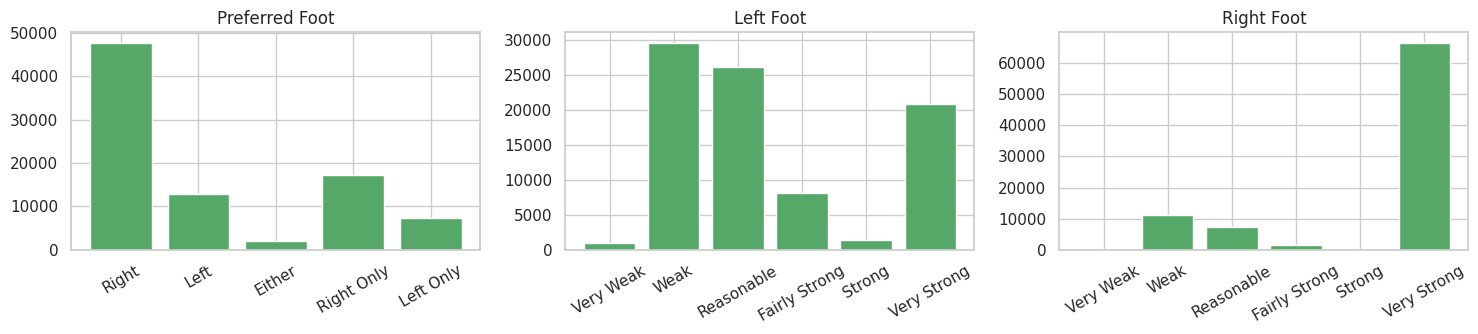

In [15]:
foot_levels = ["Very Weak", "Weak", "Reasonable", "Fairly Strong", "Strong", "Very Strong"]
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, col in zip(axes, ["Preferred Foot", "Left Foot", "Right Foot"]):
    if col == "Preferred Foot":
        order = ["Right", "Left", "Either", "Right Only", "Left Only"]
    else:
        order = foot_levels
    vc = df[col].value_counts().reindex(order).fillna(0)
    ax.bar(vc.index, vc.values, color="#55A868")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()

## 13. Síntese e próximos passos

**Estado dos dados após esta EDA:**

- 87.163 jogadores únicos (após deduplicação por `UID`).
- 60 atributos 1–20 íntegros (sem nulos), prontos para entrar em qualquer pipeline de distância.
- 7 papéis primários extraídos de `Position`, dos quais `GK` é qualitativamente distinto dos demais.
- 3 colunas string (Height, Weight, Transfer Value) ainda em formato bruto — parser de demonstração validado.
- Colunas opcionais com nulos (`Team`, `Inf`, `Club`) têm uso restrito e podem ser ignoradas pelo modelo base.

**Decisões já tomadas para o próximo passo (modelagem de similaridade):**

1. Remover `Unnamed: 0`, `Rec` e duplicatas por `UID`.
2. Segregar goleiros da análise dos jogadores de linha.
3. Trabalhar com famílias de atributos (Técnico/Mental/Físico) como conjuntos candidatos de features, em vez de tratá-las como uma soma indistinta.

**Em aberto para a próxima iteração:**

- Decidir se atributos *hidden* (personalidade, lealdade) entram nos conjuntos de features ou são tratados como variáveis de controle.
- Definir a normalização (z-score por atributo? min-max global? normalização condicional à posição?).
- Codificar `Position` como vetor binário multi-posição em vez de papel único, para a etapa de avaliação.